# Gráficos para la presentación de avance

In [2]:
from pathlib import Path
import pandas as pd

carpeta = Path("data") / "processed"

# Lee todos los CSV y los guarda en un diccionario
datasets = {
    archivo.stem: pd.read_csv(archivo)
    for archivo in carpeta.glob("*.csv")
}

# Accede a cada DataFrame por su nombre
df_ccp = datasets["dataset_entrenamiento_ccp"]
df_stgo = datasets["dataset_entrenamiento_stgo"]
dataframes  = [df_ccp, df_stgo]
display(df_ccp)
display(df_stgo)

,id_celda,target_supermercado,conteo_paraderos,conteo_convenience,conteo_mall,conteo_pharmacy,conteo_marketplace,conteo_school,conteo_university,conteo_college,conteo_hospital,conteo_clinic,conteo_sports_centre,densidad_poblacion
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0
1,1,0,0,0,0,0,0,0,0,0,0,0,0,0.0
2,2,0,0,0,0,0,0,0,0,0,0,0,0,525.0
3,3,0,0,0,0,0,0,0,0,0,0,0,0,752.0
4,4,0,0,0,0,0,0,0,0,0,0,0,0,673.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10496,10496,0,0,0,0,0,0,0,0,0,0,0,0,0.0
10497,10497,0,0,0,0,0,0,0,0,0,0,0,0,0.0
10498,10498,0,0,0,0,0,0,0,0,0,0,0,0,0.0
10499,10499,0,0,0,0,0,0,0,0,0,0,0,0,0.0


,id_celda,target_supermercado,conteo_paraderos,conteo_convenience,conteo_mall,conteo_pharmacy,conteo_marketplace,conteo_school,conteo_university,conteo_college,conteo_hospital,conteo_clinic,conteo_sports_centre,densidad_poblacion
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0
1,1,0,0,0,0,0,0,0,0,0,0,0,0,0.0
2,2,0,0,0,0,0,0,0,0,0,0,0,0,0.0
3,3,0,0,0,0,0,0,0,0,0,0,0,0,0.0
4,4,0,0,0,0,0,0,0,0,0,0,0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148906,148906,0,0,0,0,0,0,0,0,0,0,0,0,0.0
148907,148907,0,0,0,0,0,0,0,0,0,0,0,0,0.0
148908,148908,0,0,0,0,0,0,0,0,0,0,0,0,0.0
148909,148909,0,0,0,0,0,0,0,0,0,0,0,0,0.0


## 1. Matriz de Correlación de Variables Clave (Heatmap)
Para evitar un gráfico saturado en la presentación, este código selecciona los atractores comerciales y demográficos más relevantes frente a la variable objetivo. Permite justificar qué características de la celda influyen más en la decisión del modelo.

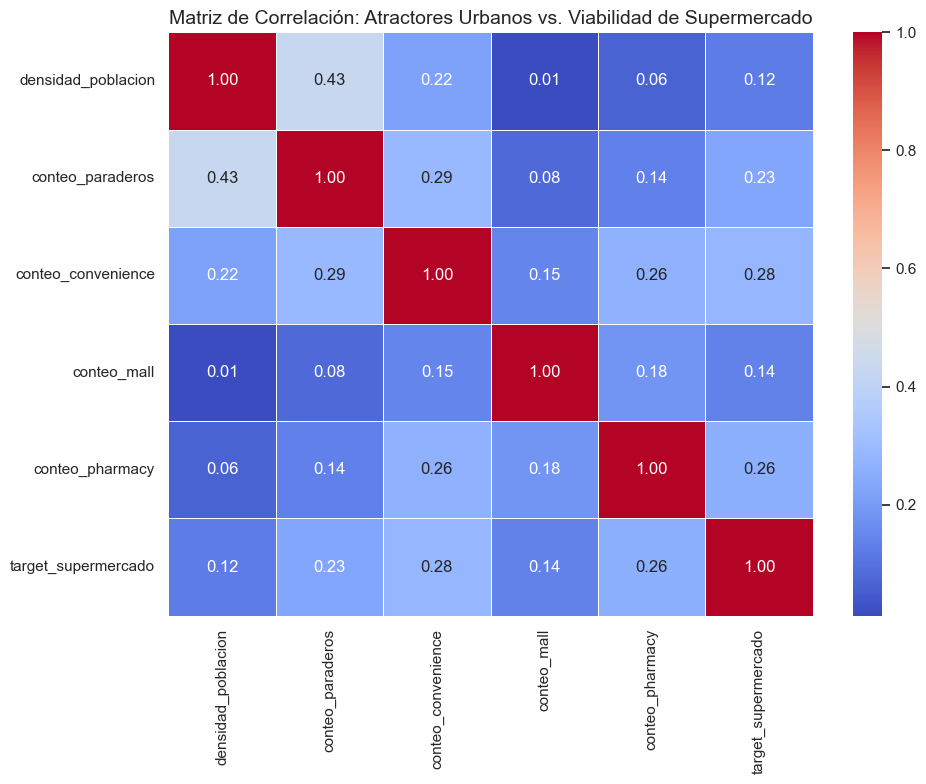

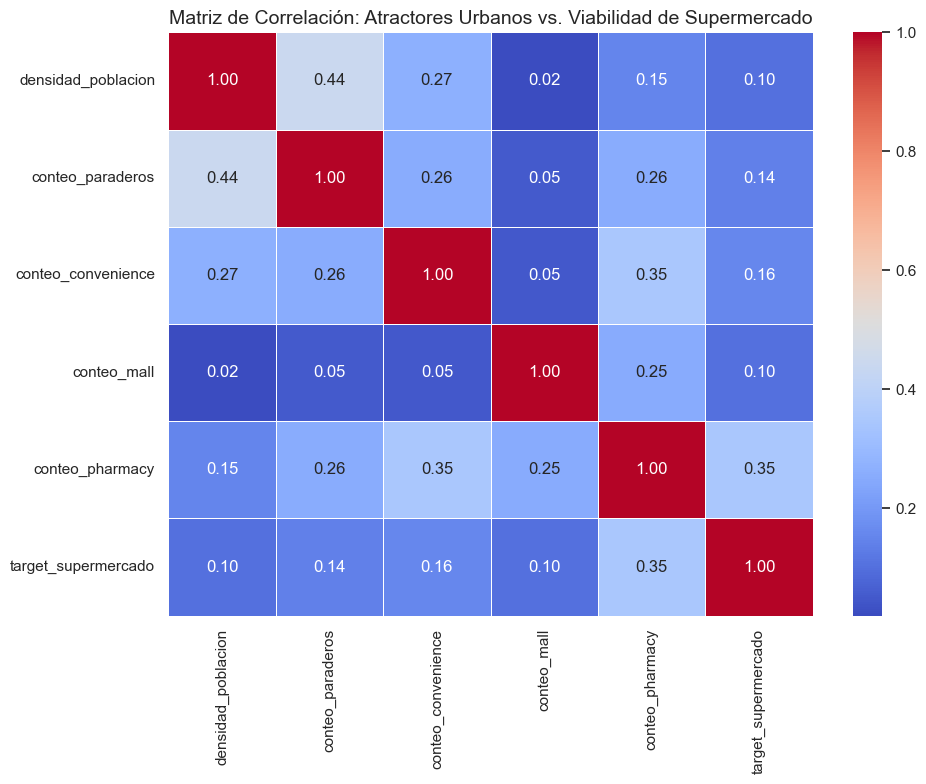

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


for df in dataframes:
    # Selección de las columnas más representativas para la presentación
    columnas_analisis = [
        'densidad_poblacion', 
        'conteo_paraderos', 
        'conteo_convenience', 
        'conteo_mall', 
        'conteo_pharmacy', 
        'target_supermercado'
    ]
    df_analisis = df[columnas_analisis]

    plt.figure(figsize=(10, 8))
    sns.heatmap(df_analisis.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
    plt.title('Matriz de Correlación: Atractores Urbanos vs. Viabilidad de Supermercado', fontsize=14)
    plt.tight_layout()
    plt.show()

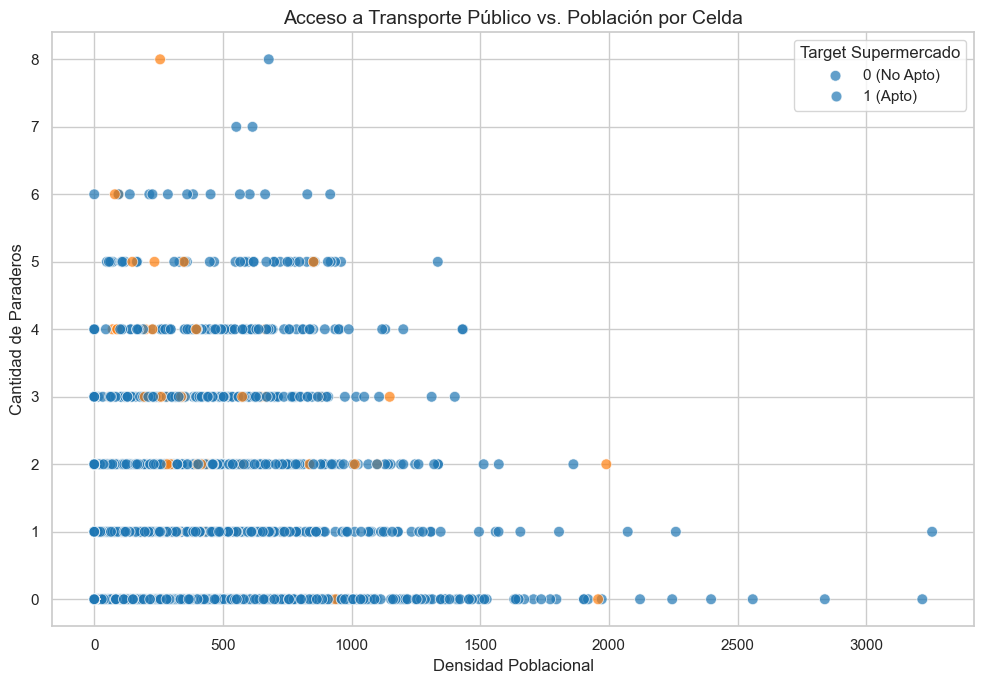

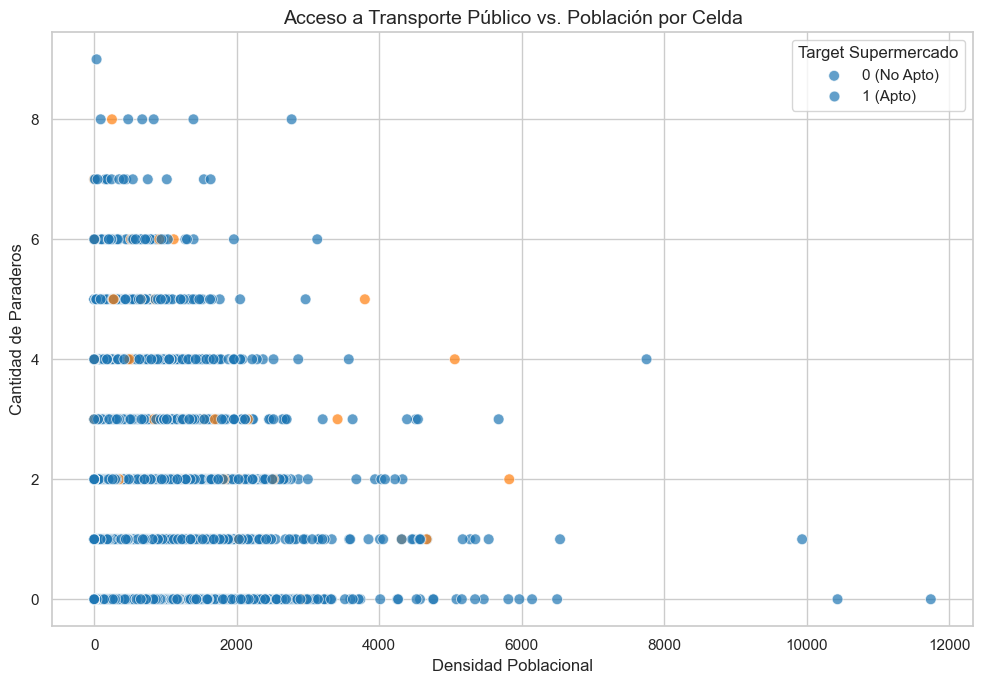

In [4]:
for df in dataframes:
    plt.figure(figsize=(10, 7))

    sns.scatterplot(
        x='densidad_poblacion', 
        y='conteo_paraderos', 
        hue='target_supermercado', 
        palette=['#1f77b4', '#ff7f0e'], 
        data=df, 
        alpha=0.7, 
        s=60
    )

    plt.title('Acceso a Transporte Público vs. Población por Celda', fontsize=14)
    plt.xlabel('Densidad Poblacional', fontsize=12)
    plt.ylabel('Cantidad de Paraderos', fontsize=12)

    plt.legend(title='Target Supermercado', labels=['0 (No Apto)', '1 (Apto)'])
    plt.tight_layout()
    plt.show()

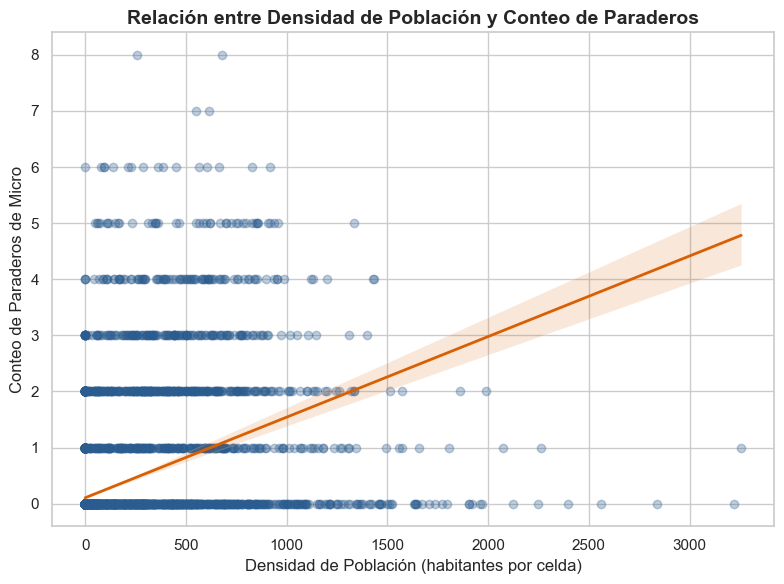

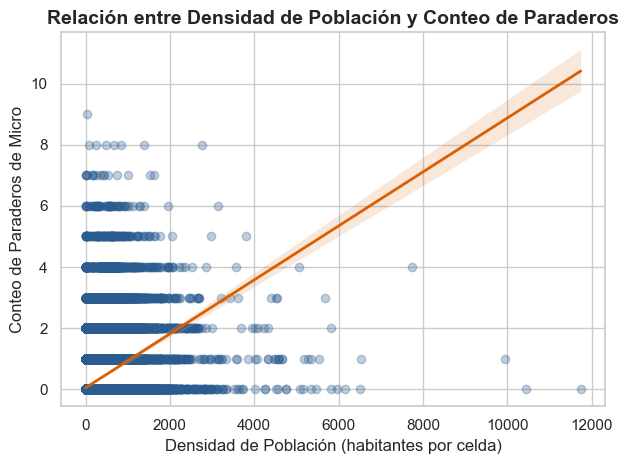

In [6]:

import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))

for df in dataframes:
    # Gráfico de dispersión con tendencia (regresión lineal simple)
    sns.regplot(
        data=df, 
        x='densidad_poblacion', 
        y='conteo_paraderos',
        scatter_kws={'alpha': 0.3, 'color': '#2b5c8f'},
    line_kws={'color': '#d95f02', 'linewidth': 2}
    )

    plt.title('Relación entre Densidad de Población y Conteo de Paraderos', fontsize=14, fontweight='bold')
    plt.xlabel('Densidad de Población (habitantes por celda)', fontsize=12)
    plt.ylabel('Conteo de Paraderos de Micro', fontsize=12)

    plt.tight_layout()
    plt.show()

C:\Users\Mateo Jr\AppData\Local\Temp\ipykernel_42244\1760837696.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


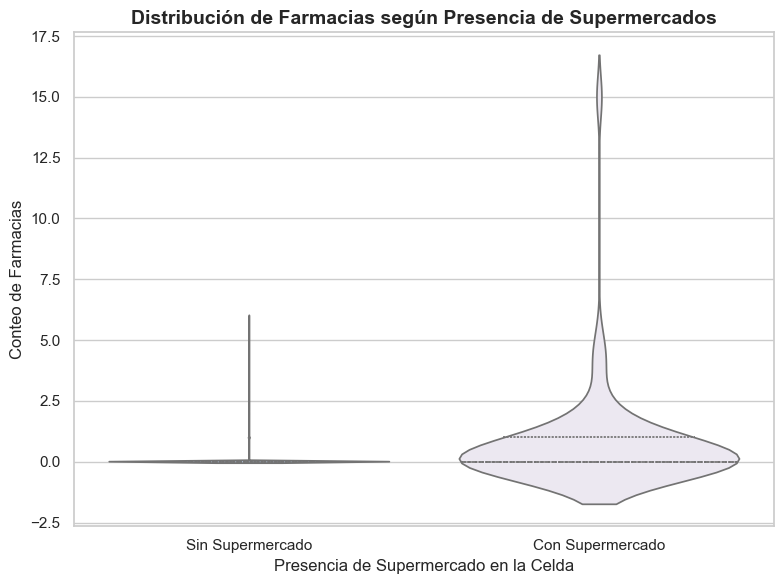

C:\Users\Mateo Jr\AppData\Local\Temp\ipykernel_42244\1760837696.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


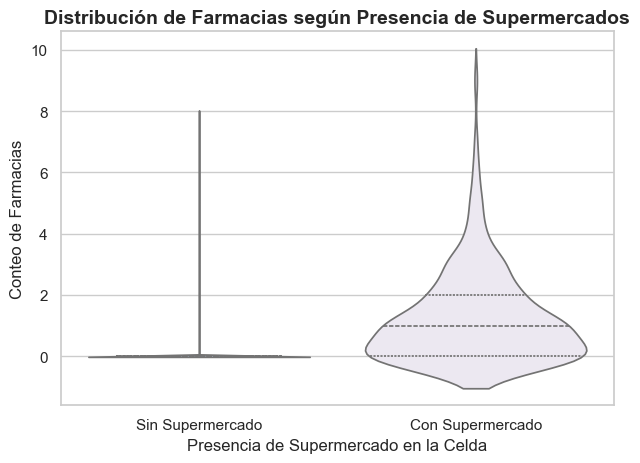

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

ciudades = {
    "Gran Concepcion": df_ccp,
    "Gran Santiago": df_stgo,
}
columnas = [
    "target_supermercado",
    "conteo_pharmacy",
    "conteo_paraderos",
    "densidad_poblacion",
]

for ciudad, datos in ciudades.items():
    faltantes = [columna for columna in columnas if columna not in datos.columns]
    if faltantes:
        raise KeyError(f"Faltan columnas en {ciudad}: {faltantes}")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("Analisis descriptivo de variables clave por ciudad", fontsize=16, fontweight="bold")

# Porcentaje de celdas con supermercado.
porcentajes = [
    ciudades[ciudad]["target_supermercado"].eq(1).mean() * 100
    for ciudad in ciudades
]
barras = axes[0, 0].bar(
    list(ciudades.keys()),
    porcentajes,
    color=["#4c78a8", "#f58518"],
)
axes[0, 0].bar_label(barras, fmt="%.1f%%", padding=3)
axes[0, 0].set_ylim(0, max(porcentajes, default=0) * 1.2 + 1)
axes[0, 0].set_title("Celdas con supermercado")
axes[0, 0].set_ylabel("Porcentaje de celdas")
axes[0, 0].tick_params(axis="x", rotation=10)

# Se muestran las distribuciones positivas en escala log para hacer visible
# la mayor parte de los valores en estas variables sesgadas.
for ax, columna, titulo, etiqueta_x in [
    (axes[0, 1], "conteo_pharmacy", "Farmacias por celda", "Cantidad de farmacias"),
    (axes[1, 0], "conteo_paraderos", "Paraderos de buses por celda", "Cantidad de paraderos"),
    (axes[1, 1], "densidad_poblacion", "Poblacion por celda", "Habitantes por celda"),
]:
    valores_positivos = []
    etiquetas = []
    for ciudad, datos in ciudades.items():
        valores = pd.to_numeric(datos[columna], errors="raise").dropna()
        positivos = valores[valores > 0]
        if positivos.empty:
            raise ValueError(f"No hay valores positivos para {titulo.lower()} en {ciudad}.")
        porcentaje_cero = valores.eq(0).mean() * 100
        valores_positivos.append(positivos)
        etiquetas.append(f"{ciudad} (0: {porcentaje_cero:.1f}%)")

    ax.boxplot(valores_positivos, vert=False, tick_labels=etiquetas, showfliers=False)
    ax.set_xscale("log")
    ax.set_title(titulo)
    ax.set_xlabel(f"{etiqueta_x} (escala log; solo celdas con valor > 0)")
    ax.grid(axis="x", linestyle="--", alpha=0.5)

fig.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()